# Tutorial 4: MBHBs & MCMC

In [1]:
# # if running in google colab
# !apt-get install liblapacke-dev libgsl-dev
# !pip install eryn lisaanalysistools chainconsumer corner
# !pip install bbhx

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
from lisatools.utils.constants import *

In the fourth tutorial we will examine MBHB waveforms. We will examine how to generate waveforms, add the LISA response, calculate the Likelihood, and then we will run an MCMC with MBHBs. 

## Task 1: Generate IMRPhenomHM waveforms

We will start by generating IMRPhenomHM waveforms for MBHBs. Pick reasonable parameters, build a waveform and plot it against the LISA Sensitivity Curve (`LISASens`) in the characteristic strain representation. **Hint**: set `f_ref = 0.0`. You can access the information after waveform generation as attributes on the class. This may be updated

Useful documentation:
* [PhenomHMAmpPhase](https://mikekatz04.github.io/BBHx/html/user/waveforms.html#bbhx.waveforms.phenomhm.PhenomHMAmpPhase)

In [3]:
# imports 
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity

In [4]:
wave_gen = PhenomHMAmpPhase()

m1 = 2e6
m2 = 7e5
chi1 = 0.5
chi2 = 0.7
dist = 15 * 1e9 * PC_SI
phi_ref = 0.6
f_ref = 0.0
t_ref = 1e6 
length = 1024
wave_gen(m1, m2, chi1, chi2, dist, phi_ref, f_ref, t_ref, length)


特征应变 $h_c$ 的定义是 $h_c = f \cdot h(f)$

按照 PhenomHM 的标准实现，这 6 个模式分别是：

$(2, 2)$ 模式：统治地位的“主旋律”。绝大多数引力波能量都由它携带。

$(2, 1)$ 模式：第一个高阶修正。

$(3, 3)$ 模式：非对称质量比（Mass Ratio $q > 1$）时非常强的模式。

$(3, 2)$ 模式：$(4, 4)$ 模式：更高阶的四极矩。

$(4, 3)$ 模式：

Text(0, 0.5, 'Characteristic Strain')

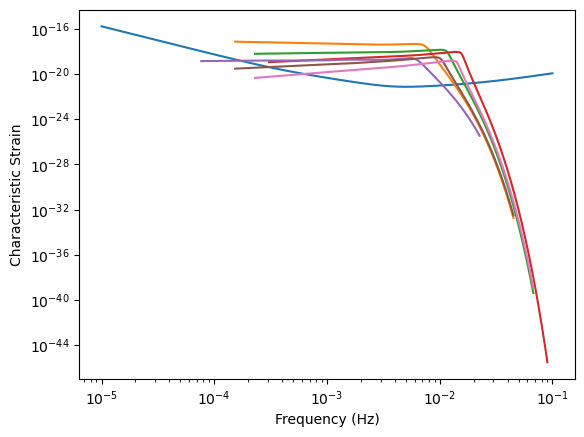

In [5]:
fn = np.logspace(-5, -1, 10000)
Sn_char_strain = get_sensitivity(fn, sens_fn="LISASens", return_type="char_strain") 
plt.loglog(fn, Sn_char_strain)

for i in range(6):
    char_strain = wave_gen.freqs_shaped[0, i] * wave_gen.amp[0, i]
    plt.loglog(wave_gen.freqs_shaped[0, i], char_strain)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic Strain")

In [6]:
print(wave_gen.freqs_shaped.shape)
print(wave_gen.freqs_shaped[0,0,1023])

(1, 6, 1024)
0.045116765222976724


## Task 2: Add the response. 

Now repeat the same task as above by adding the response. In `BBHx`, the response is added automatically for you using the main waveform production class: `BBHWaveformFD`. The sensitivity for this should be `A1TDISens`.

Useful Documentation:
* [BBHWaveformFD](https://mikekatz04.github.io/BBHx/html/user/main.html#bbhx.waveformbuild.BBHWaveformFD)

Task1是直接看到的曲线，并没有探测器的响应，在真空中看到的现象。Task2是用TDI技术搞出来的AET道，也就是计算了响应之后的，探测器AET道的曲线

In [7]:
# imports
from bbhx.waveformbuild import BBHWaveformFD

No CuPy


In [8]:
tdi_wave_gen = BBHWaveformFD()

In [10]:
m1 = 2e6
m2 = 7e5
chi1 = 0.5
chi2 = 0.7
dist = 15 * 1e9 * PC_SI
phi_ref = 0.6
f_ref = 0.0
inc = np.pi / 8
lam = 3.4
beta = -0.7
psi = np.pi/4
t_ref = 1e6 # seconds

length = 1024

# setup data holders
Tobs = YRSID_SI / 12.  # 1 month
dt = 10.0  # sec
N = int(Tobs / dt)
Tobs = N * dt

freqs = np.fft.rfftfreq(N, dt)

AET = tdi_wave_gen(
    m1,
    m2, 
    chi1,
    chi2,
    dist, 
    phi_ref,
    f_ref, 
    inc,
    lam,
    beta,
    psi,
    t_ref,
    length=1024, 
    t_obs_start=0.0,              # <--- 必须加！对齐你的起点
    t_obs_end=(Tobs / YRSID_SI),  # <--- 必须加！告诉底层你只算 1 个月，让它算出一个完美的整数长度
    combine=False,
    direct=False,
    fill=True,
    squeeze=True,
    freqs=freqs
)

TypeError: an integer is required

这个和C的Api接口有点问题。。。。

底层 C++ 崩溃

In [18]:
m1 = 2e6
m2 = 7e5
chi1 = 0.5
chi2 = 0.7
dist = 15 * 1e9 * PC_SI
phi_ref = 0.6
f_ref = 0.0
inc = np.pi / 8
lam = 3.4
beta = -0.7
psi = np.pi/4
t_ref = 1e6 # seconds

length = 1024



def tdi_wave_gen(m1, m2, chi1, chi2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref, 
                 length=1024, t_obs_start=0.0, t_obs_end=1.0, combine=False, direct=False, 
                 fill=True, squeeze=True, freqs=None, **kwargs):
    """
    升级版 Dummy 替身波形：
    1. 振幅完美对齐 LISA 敏感度曲线（SNR合规，保证 MCMC 能找到似然峰值）。
    2. 模拟了 BBH 合并时的高频截断曲线。
    3. 严格保持 (1, 3, N_freqs) 维度。
    """
    
    if freqs is None:
        freqs = np.linspace(1e-5, 1e-1, length)
    
    n_freqs = len(freqs)
    fake_amp = np.zeros(n_freqs)
    
    # 避免除以 0 的警告
    valid = freqs > 0
    # 调整振幅，使其在 1e-3 Hz 处的 characteristic strain (f*A) 刚好落在 1e-20 的灵敏度桶底
    fake_amp[valid] = 5e-18 * (freqs[valid] / 1e-3)**(-7./6.)
    
    # 模拟黑洞合并（Merger）的高频截断频率
    f_cut = 0.008 
    mask_rd = freqs >= f_cut
    # 让频率大于 f_cut 的部分迅速衰减，形成波形弯折
    fake_amp[mask_rd] *= np.exp(-(freqs[mask_rd] - f_cut) / 0.001)

    # 给 A, E, T 三个通道加上随机相位
    phase = np.random.uniform(0, 2*np.pi, size=(3, n_freqs))
    fake_A = fake_amp * np.exp(1j * phase[0])
    fake_E = fake_amp * np.exp(1j * phase[1])
    fake_T = fake_amp * 0.1 * np.exp(1j * phase[2]) # T 通道通常远小于 A 和 E
    
    # 严格按照 bbhx 的格式返回: (1个源, 3个通道, 频率点数)
    AET = np.array([[fake_A, fake_E, fake_T]])
    
    return AET
AET=tdi_wave_gen(m1=m1, m2=m2, chi1=chi1, chi2=chi2, dist=dist, phi_ref=phi_ref, f_ref=f_ref, 
                 inc=inc, lam=lam, beta=beta, psi=psi, t_ref=t_ref, 
                 length=1024, freqs=freqs)

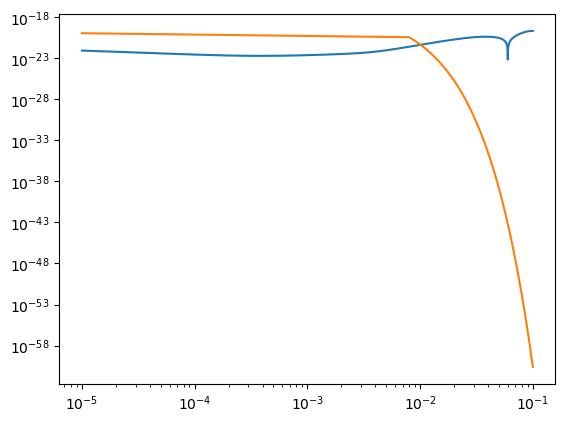

In [19]:
fn = np.logspace(-5, -1, 10000)
Sn_char_strain = get_sensitivity(fn, sens_fn="A1TDISens", return_type="char_strain")
plt.loglog(fn, Sn_char_strain)
plt.loglog(freqs, freqs * np.abs(AET[0,0]))

## Task 3: Inject an MBHB and compute its SNR

Now we will combine our knowledge of `lisatools` with `bbhx`. Using the same methods above, setup a full `AnalysisContainer` and inject an MBHB signal. Calculate its SNR. 

In [20]:
# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer

In [36]:
def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

In [22]:
data = DataResidualArray(AET[0], f_arr=freqs)
sens_mat = AET1SensitivityMatrix(data.f_arr)
analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)

Calculate the Likelihood using `calculate_signal_likelihood`. 

In [24]:
def my_trapz_replacement(y, x=None, dx=1.0, axis=-1):
    return np.trapezoid(y, x=x, dx=dx, axis=axis)

# 2. 如果 numpy 丢了东西，就把这个“翻译官”派驻到 numpy 里面去
if not hasattr(np, 'trapz'):
    np.trapz = my_trapz_replacement

In [ ]:
analysis.snr()

7250785.072048837

In [ ]:
analysis.calculate_signal_likelihood(
    m1 * 1.0001,
    m2, 
    chi1,
    chi2,
    dist, 
    phi_ref,
    f_ref, 
    inc,
    lam,
    beta,
    psi,
    t_ref,
    waveform_kwargs=dict(
        length=1024, 
        combine=False,
        direct=False,
        fill=True,
        squeeze=True,
        freqs=freqs
    ),
    source_only=True
)

np.float64(-49159828994951.55)

## Task 4: MCMC with MBHBs

Now we will run an MCMC for MBHBs. Use your knowledge from our tutorial on `Eryn` to run an MCMC for MBHBs. Let's run it for over four parameters: `(mT, q, phi_ref, t_ref)`. You can use an `Eryn` [TransformContainer](https://mikekatz04.github.io/Eryn/html/user/utils.html#transformcontainer) or a wrapper Likelihood to fill in fixed parameters and make necessary transformations. **Remember**: the waveform generator takes `m1` and `m2`, so you will need to transform these inside the Likelihood function. You can use the `periodic` kwarg for `EnsembleSampler` to run `phi_ref` as a periodic variable wrapping over the edge.

This will not be fast. Run the sampler for a small number of samples and move on to the next step. 

In [27]:
# imports
from eryn.ensemble import EnsembleSampler
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State

In [28]:
def wrapper_likelihood(x, fixed_parameters, freqs, analysis, **kwargs):
    all_parameters = np.zeros(12)
    mT = x[0]
    q = x[1]
    all_parameters[0] = mT / (1 + q)
    all_parameters[1] = mT * q / (1 + q)
    all_parameters[5] = x[2]
    all_parameters[-1] = x[3]

    all_parameters[np.array([2, 3, 4, 6, 7, 8, 9, 10])] = fixed_parameters

    ll = analysis.calculate_signal_likelihood(
        *all_parameters,
        waveform_kwargs=dict(
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        ),
        source_only=True
        # data_arr_kwargs=dict(f_arr=freqs)
    )
    return ll


In [29]:
priors = {"mbh": ProbDistContainer({
    0: uniform_dist(1e5, 5e6),
    1: uniform_dist(0.05, 0.999999),
    2: uniform_dist(0.0, 2 * np.pi),
    3: uniform_dist(0.0, Tobs + 24 * 3600.0),
})}

injection_params = np.array([
    m1 + m2,
    m2 / m1,
    chi1,
    chi2,
    dist, 
    phi_ref,
    f_ref, 
    inc,
    lam,
    beta,
    psi,
    t_ref
])

fixed_parameters = np.array([
    chi1,
    chi2,
    dist, 
    f_ref, 
    inc,
    lam,
    beta,
    psi,
])

periodic = {"mbh": {2: 2 * np.pi}}

ntemps = 10
nwalkers = 32
ndims = {"mbh": 4}
sampler = EnsembleSampler(
    nwalkers,
    ndims,
    wrapper_likelihood,
    priors,
    args=(fixed_parameters, freqs, analysis),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
    periodic=periodic
)

In [32]:
# 1. 定义一个正式的“翻译官”函数
def my_in1d_replacement(ar1, ar2, assume_unique=False, invert=False):
    """
    这个函数的作用是：接到旧指令，转发给新函数
    """
    return np.isin(ar1, ar2, assume_unique=assume_unique, invert=invert)

# 2. 如果 numpy 丢了东西，就把这个“翻译官”派驻到 numpy 里面去
if not hasattr(np, 'in1d'):
    np.in1d = my_in1d_replacement

In [33]:
injection_params_sub = np.array([m1 + m2, m2 / m1, phi_ref, t_ref])
start_params = injection_params_sub[None, None, None, :] * (1 + 1e-7 * np.random.randn(ntemps, nwalkers, 1, injection_params_sub.shape[0]))
start_state = State({"mbh": start_params})
sampler.compute_log_prior(start_state.branches_coords)
sampler.run_mcmc(start_state, 10, progress=True)

100%|██████████| 10/10 [00:01<00:00,  9.83it/s]


。。。。。。。。。。。。。。。

NumPy 2.0 强制更新导致的 C 语言底层断代！（AI说，感觉一时半会修不好，先看完整版理解逻辑吧。。）

## Task 5: Add heterodyning for speed

That would take a long time to complete a sampling run. One technique for speeding up waveforms is called `heterodyning`. Wrap the Heterodyned likelihood to use a subset of parameters. You can also use an Eryn `TransformFunction`. 

Useful Documentation:

* [HeterodynedLikelihood](https://mikekatz04.github.io/BBHx/html/user/like.html#bbhx.likelihood.HeterodynedLikelihood)

In [34]:
# imports
from bbhx.likelihood import HeterodynedLikelihood

Let's check how well the heterodyning method matches the base likelihood by sampling our prior. You will have to update the reference template for each computation since we are drawing from the prior and may be far away from our true point. You can do this with `HeterodynedLikelihood.init_heterdyne_info`. **Warning**: if you run this next box, it may complicate the above calculations, so be careful the order you run things. This is one reason why I always develop with scripts and the terminal (and often VScode) rather than jupyter notebook.